# Lab Session 1 Part 1


Python / Google Colab

This practical introduces graphical data exploration in Python. We use pandas to organise data, matplotlib and seaborn to create static graphics, and plotly for an interactive map.

Learning outcomes

By the end of the practical (this Part and Part 2), you should be able to:

inspect a dataset before analysis;
choose a suitable graph for categorical, quantitative, temporal and spatial data;
produce bar charts, pie charts, histograms, box plots, scatter plots and line plots;
customise labels, colours and plotting symbols;
split a graph into separate panels using faceting;
explain what a graph reveals about a dataset.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


## Example 1: Drug Costs Dataset

In [2]:
data = pd.read_csv("Data/drugcosts.csv")
values = data.iloc[:,0]

print("Sample size:", len(values))
print("Mean:", values.mean())
print("Median:", values.median())
print("Variance:", values.var())
print("SD:", values.std())
print("Min:", values.min())
print("Max:", values.max())
print("Range:", values.max()-values.min())
print("Q1:", values.quantile(0.25))
print("Q3:", values.quantile(0.75))
print("IQR:", values.quantile(0.75)-values.quantile(0.25))

Sample size: 84
Mean: 75.05952380952381
Median: 51.099999999999994
Variance: 4494.9140045897875
SD: 67.04411983604369
Min: 2.0
Max: 320.4
Range: 318.4
Q1: 29.275
Q3: 94.0
IQR: 64.725


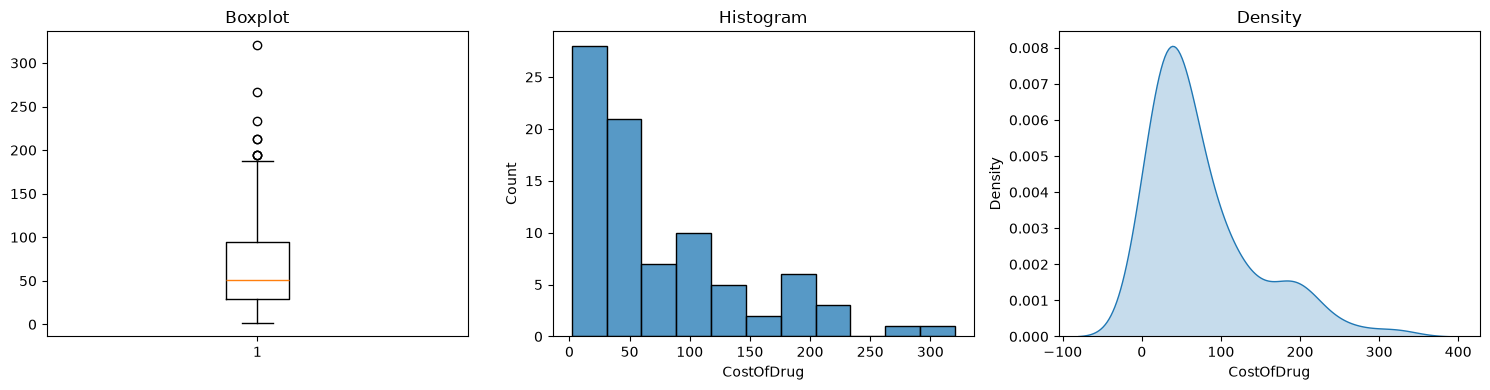

In [3]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
ax[0].boxplot(values)
ax[0].set_title("Boxplot")
sns.histplot(values,ax=ax[1])
ax[1].set_title("Histogram")
sns.kdeplot(values,ax=ax[2],fill=True)
ax[2].set_title("Density")
plt.tight_layout()

## Example 2: West Nile Virus Surveillance Data

In [4]:
# Load WNV dataset from a CSV export if available
wnv = pd.read_csv("Data/wnv.csv")
wnv.head(25)

,id,county,age,sex,syndrome,date.onset,date.tested,death
0,1,San Bernardino,40.0,F,WNF,2004-05-19,2004-06-02,No
1,2,San Bernardino,64.0,F,WNF,2004-05-22,2004-06-16,No
2,3,San Bernardino,19.0,M,WNF,2004-05-22,2004-06-16,No
3,4,San Bernardino,12.0,M,WNF,2004-05-16,2004-06-16,No
4,5,San Bernardino,12.0,M,WNF,2004-05-14,2004-06-16,No
5,6,San Bernardino,17.0,M,WNF,2004-06-07,2004-06-17,No
6,7,San Bernardino,61.0,M,WNND,2004-06-09,2004-06-18,No
7,8,San Bernardino,74.0,F,WNND,2004-06-14,2004-06-22,No
8,9,Los Angeles,71.0,M,WNF,2004-06-09,2004-06-24,No
9,10,Riverside,26.0,M,WNND,2004-06-13,2004-06-24,No


In [5]:
wnv["date.onset"] = pd.to_datetime(wnv["date.onset"])
wnv["date.tested"] = pd.to_datetime(wnv["date.tested"])

wnv["sex"].describe()

count     759
unique      2
top         M
freq      474
Name: sex, dtype: object

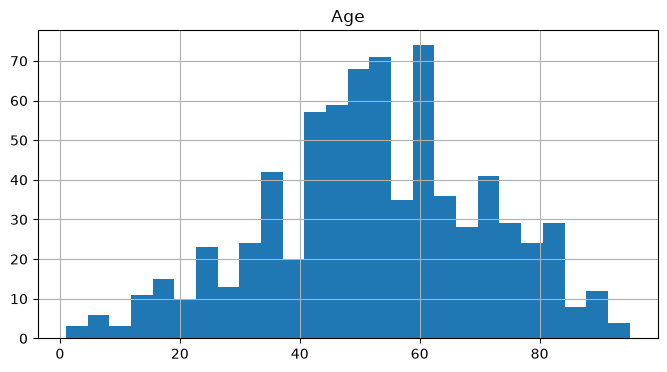

In [6]:
plt.figure(figsize=(8,4))
wnv["age"].hist(bins=26)
plt.title("Age")
plt.show()

In [7]:
sex_counts = wnv["sex"].value_counts(dropna=False)
sex_props = wnv["sex"].value_counts(normalize=True, dropna=False)
pd.concat([sex_counts, sex_props], axis=1, keys=["count","proportion"])

,count,proportion
sex,,
M,474,0.618799
F,285,0.372063
NaN,7,0.009138


In [8]:
wnv.groupby("sex")["age"].mean()

sex
F    53.799283
M    51.915948
Name: age, dtype: float64

In [9]:
wnv["age_group"] = pd.cut(wnv["age"], bins=[0,70,100], right=False)
ct = pd.crosstab(wnv["age_group"], wnv["death"])
ct

death,No,Yes
age_group,,
"[0, 70)",432,7
"[70, 100)",98,16


In [10]:
from scipy.stats import chi2_contingency, fisher_exact

chi2,p,dof,expected = chi2_contingency(ct)
print("Chi-square p-value:", p)

if ct.shape == (2,2):
    oddsratio, fp = fisher_exact(ct)
    print("Odds ratio:", oddsratio)
    print("Fisher p-value:", fp)

Chi-square p-value: 1.4751090478961323e-08
Odds ratio: 10.075801749271138
Fisher p-value: 2.865951329418369e-07


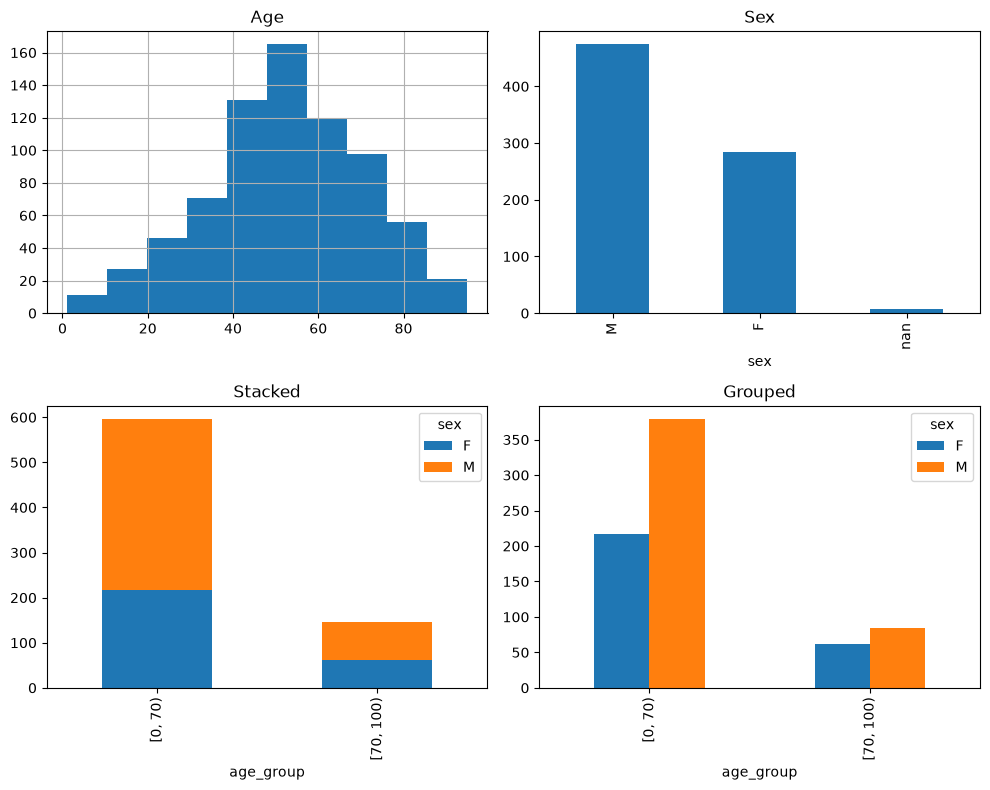

In [11]:
fig,ax=plt.subplots(2,2,figsize=(10,8))
wnv["age"].hist(ax=ax[0,0])
ax[0,0].set_title("Age")
sex_counts.plot(kind="bar",ax=ax[0,1])
ax[0,1].set_title("Sex")
pd.crosstab(wnv["age_group"],wnv["sex"]).plot(kind="bar",stacked=True,ax=ax[1,0])
ax[1,0].set_title("Stacked")
pd.crosstab(wnv["age_group"],wnv["sex"]).plot(kind="bar",ax=ax[1,1])
ax[1,1].set_title("Grouped")
plt.tight_layout()